# Data Visualization for SCBA data
Dec 5, 2025: Put the data management and loading and plotting in a class `SCBAData` to handle it all. The data is concatenated in Quatrex before saving, so the data is without ranks when it's loaded here.

The data format is: [iteration, energy, sample_number]. 

1. iteration index - Usually between 2-20
2. energy index - Usually 256-1024. To calculate the physical domain in eV, use the `QuatrexConfig` data object `config`. This is stored for you in the `SCBAData` data object (ex. `SCBAData.energy_window_min`).
3. sample number - Sample index of the of non-zero indices to save. The Green's function matrix per each energy index is 768x768 = 589824. But only 43824 entries (7.43%) are filled. But 43824 entries are still too much to save, so we only save 100 of them, which are randomly generated. This is hardcoded in Quatrex in `scba.py`. The file `..._sample_indices.py` tells which real nnz index corresponds to the sample index. Ex. sample index 3/100 is actually nnz index 1311/43824.

## single iteration and nnz index
Plotting from `archive/` directory, not the active `outputs/` directory.

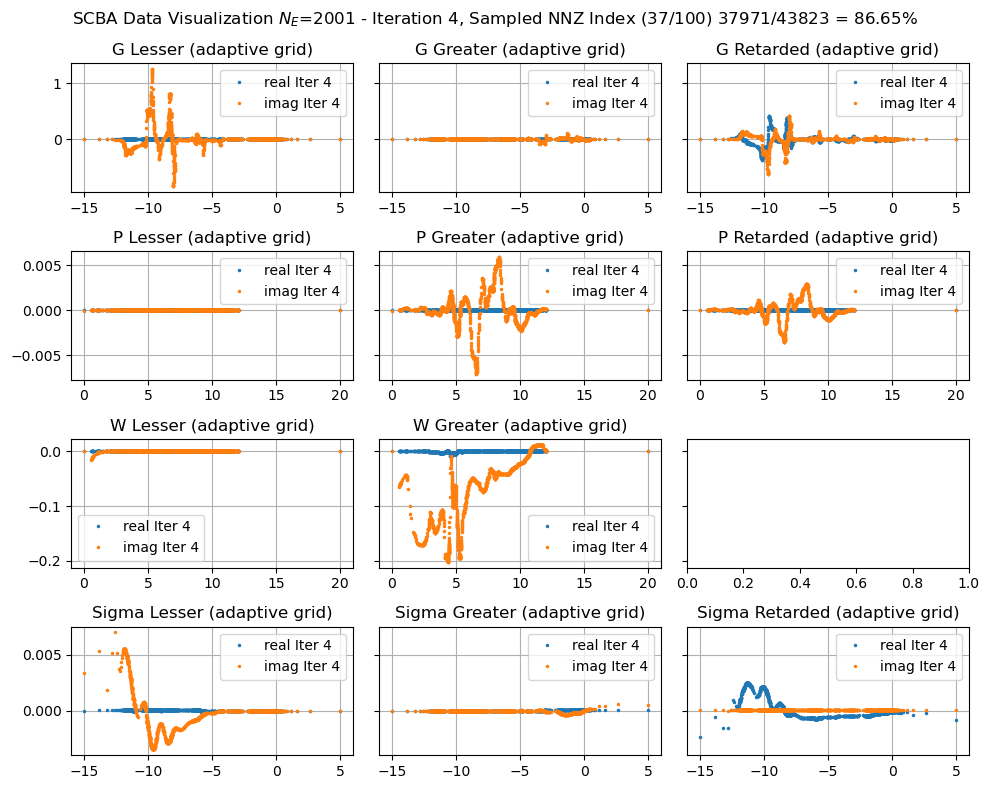

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# data class to hold data across iterations
from scba_container.scba_container import SCBAContainer

from quatrex.core.config import parse_config
from pathlib import Path

# band-limited study (symmetrization on)
# 20260319_160518_energy201_iter20_reduced
# 20260319_154430_energy2001_iter20_reduced                     # reference, 20 iterations
# 20260319_161440_energy20001_iter5_reduced

# symmetrization off, reference
# 20260410_145015_energy201_iter20_rank125, 201 energies, 125 ranks
# 20260410_145402_energy2001_iter20_rank125, 2001 energies, 125 ranks
# 20260415_141726_energy2001_iter100_rank250, same^, but 100 iterations and 250 ranks
# 20260416_145226_energy2001_iter100_rank250, ^same, but nevp solver is 'full' instead of 'beyn'
# 20260410_151602_energy20001_iter20_rank125, 20001 energies, 125 ranks -- max RAM usage over 512G, ~680G

# sanity check
# 20260326_153844_energy2001_iter20_adaptive_iter1_r1_reduced_sanity_check         # interpolation workflow, but _compute_adaptive_grid returns uniform grid

# adaptive, symmetrization off, varying r
# 20260413_162909_adaptive_energy2001_start1_r1_iter20_rank250
# 20260415_120205_adaptive_energy2001_start1_r1_iter100_rank250         # same as above, but 100 iterations
# 20260416_154143_adaptive_energy2001_start1_r1_iter100_rank250         # ^same, but nevp solver is 'full' instead of 'beyn'
# 20260413_134004_adaptive_energy2001_start1_r5_iter20_rank125
# 20260413_190942_adaptive_energy2001_start1_r5_iter20_rank250      # same as above, but 250 ranks
# 20260413_170105_adaptive_energy2001_start1_r0p5_iter20_rank250

# adaptive, symmetrization off, varying adaptive start iteration
# 20260414_152126_adaptive_energy2001_start2_r1_iter20_rank250
# 20260414_162256_adaptive_energy2001_start5_r1_iter20_rank250

simulation_dir = Path("./../../examples/w90/carbon-nanotube/gw")
output_dir = simulation_dir / "outputs"
output_file_prefix = output_dir / "visualize_scba"
archive_dir = simulation_dir / "archive" / "20260416_154143_adaptive_energy2001_start1_r1_iter100_rank250"
archive_file_prefix = archive_dir / "visualize_scba"

# change these to switch between 'output' and 'archive'
data_files = 'archive'  # 'archive' or 'output'

# === user parameters ===
iteration_to_plot = 4
sample_idx_to_plot = 37

# region: === load data ===
if data_files == 'output':
    data_file_prefix = output_file_prefix
    data_dir = output_dir
    config_dir = simulation_dir
elif data_files == 'archive':
    data_file_prefix = archive_file_prefix
    data_dir = archive_dir
    config_dir = archive_dir
else:
    raise ValueError(f"Invalid data_files value: {data_files}. Must be 'output' or 'archive'.")

config = parse_config(config_dir / "quatrex_config.toml")

max_idx = 43823  # total nnz entries - 1
sample_indices = np.load(f"{data_file_prefix}_sample_indices.npy")
num_samples = len(sample_indices)

SCBADataObj = SCBAContainer(
    max_iterations=config.scba.max_iterations,
    energy_window_min=config.electron.energy_window_min,
    energy_window_max=config.electron.energy_window_max,
    energy_window_num=config.electron.energy_window_num,
    num_samples=num_samples,
)

SCBADataObj.load_sample_indices(data_file_prefix)
SCBADataObj.load_adaptive_grids(data_dir)

for i in range(config.scba.max_iterations):
    SCBADataObj.load_g_data(data_file_prefix, iteration=i)
    SCBADataObj.load_p_data(data_file_prefix, iteration=i)
    SCBADataObj.load_w_data(data_file_prefix, iteration=i)
    SCBADataObj.load_sigma_data(data_file_prefix, iteration=i)

assert (
    sample_idx_to_plot <= num_samples
), f"sample_idx_to_plot={sample_idx_to_plot} exceeds num_samples={num_samples}"
nnz_index_to_plot = SCBADataObj.sample_indices[sample_idx_to_plot]
# endregion

# region: === plotting ===
fig, axs = plt.subplots(4, 3, figsize=(10, 8), sharey='row')

SCBADataObj.plot_iteration(
    axs,
    iteration_to_plot,
    sample_idx_to_plot,
    adaptive_start_iteration=config.scba.adaptive_start_iteration
)

fig.suptitle(
    f"SCBA Data Visualization $N_E$={config.electron.energy_window_num} - Iteration {iteration_to_plot}, Sampled NNZ Index ({sample_idx_to_plot}/{num_samples}) {nnz_index_to_plot}/{max_idx} = {nnz_index_to_plot/max_idx:.2%}"
)
plt.tight_layout()
plt.show()
# endregion


## saving separate plots for each iteration

In [2]:
# save separate plots for all iterations
plot_dir = simulation_dir / "plots"

# switch to not accidentally save a lot of plots
save_plots = False

if save_plots:
    for iteration_to_plot in range(config.scba.max_iterations):
        fig, axs = plt.subplots(4, 3, figsize=(10, 8))
        # iteration_to_plot = 0
        sample_idx_to_plot = 34
        assert (
            sample_idx_to_plot <= num_samples
        ), f"sample_idx_to_plot={sample_idx_to_plot} exceeds num_samples={num_samples}"
        nnz_index_to_plot = SCBADataObj.sample_indices[sample_idx_to_plot]

        SCBADataObj.plot_iteration(
            axs,
            iteration_to_plot,
            sample_idx_to_plot,
        )

        fig.suptitle(
            f"SCBA Data Visualization $N_E$={config.electron.energy_window_num} - Iteration {iteration_to_plot}, Sampled NNZ Index {nnz_index_to_plot}/{max_idx} = {nnz_index_to_plot/max_idx:.2%}"
        )
        plt.tight_layout()
        plt.savefig(
            plot_dir
            / f"scba_iteration{iteration_to_plot:03}_sample_nnzIdx{sample_idx_to_plot}.png"
        )
        print(
            f"saved plot for iteration {iteration_to_plot} at {plot_dir / f'scba_iteration{iteration_to_plot:03}_sample_nnzIdx{sample_idx_to_plot}.png'}"
        )

## plot multiple iterations on top of each other with fading alpha

Plotted iteration 0 with alpha=0.30
Plotted iteration 1 with alpha=0.34
Plotted iteration 2 with alpha=0.37
Plotted iteration 3 with alpha=0.41
Plotted iteration 4 with alpha=0.45
Plotted iteration 5 with alpha=0.48
Plotted iteration 6 with alpha=0.52
Plotted iteration 7 with alpha=0.56
Plotted iteration 8 with alpha=0.59
Plotted iteration 9 with alpha=0.63
Plotted iteration 10 with alpha=0.67
Plotted iteration 11 with alpha=0.71
Plotted iteration 12 with alpha=0.74
Plotted iteration 13 with alpha=0.78
Plotted iteration 14 with alpha=0.82
Plotted iteration 15 with alpha=0.85
Plotted iteration 16 with alpha=0.89
Plotted iteration 17 with alpha=0.93
Plotted iteration 18 with alpha=0.96
Plotted iteration 19 with alpha=1.00


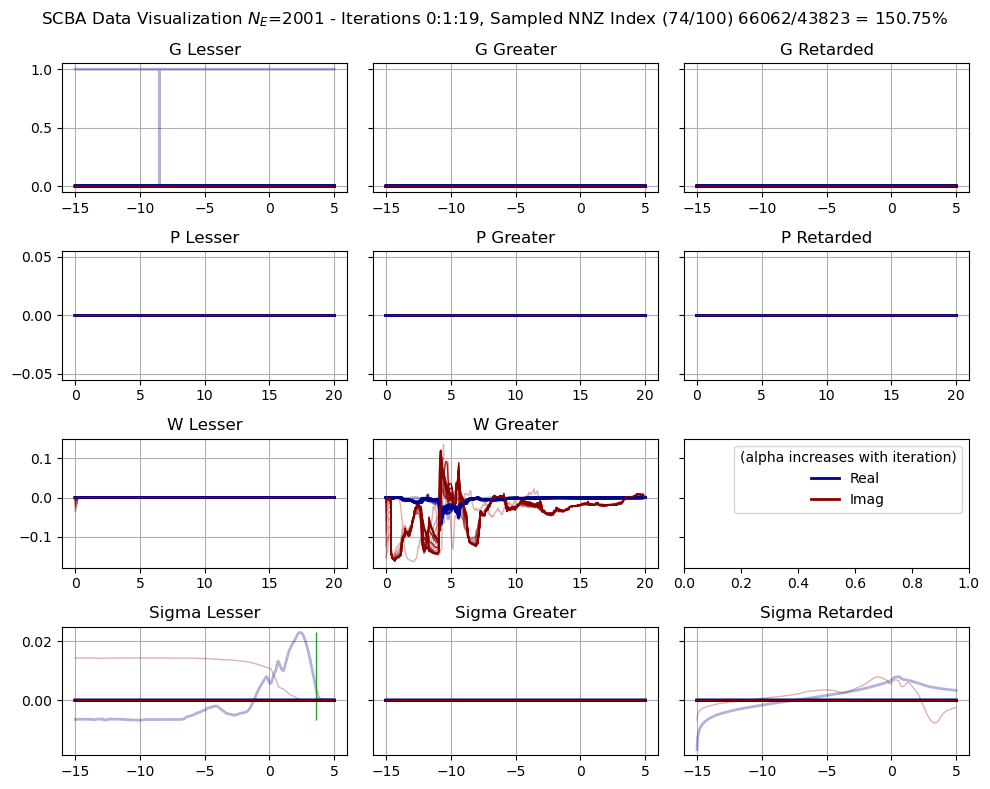

In [3]:
# custom legend
from matplotlib.lines import Line2D

# === plot iteration on top of each other with changing alpha ===
fig, axs = plt.subplots(4, 3, figsize=(10, 8), sharey='row')

# === user parameters ===
sample_idx_to_plot = 74

iterations = range(0, config.scba.max_iterations)
# iterations = range(0, 3)

colorReal = "darkblue"
colorImag = "darkred"

# region: === plotting ===
for iteration_to_plot in iterations:
    assert (
        sample_idx_to_plot <= num_samples
    ), f"sample_idx_to_plot={sample_idx_to_plot} exceeds num_samples={num_samples}"
    nnz_index_to_plot = SCBADataObj.sample_indices[sample_idx_to_plot]

    SCBADataObj.plot_iteration(
        axs,
        iteration_to_plot,
        sample_idx_to_plot,
        alpha=0.3 + 0.7 * (iteration_to_plot / (config.scba.max_iterations - 1)),
        colorReal=colorReal,
        colorImag=colorImag,
        linewidthReal=2,
        linewidthImag=1,
    )

    print(
        f"Plotted iteration {iteration_to_plot} with alpha={0.3 + 0.7 * (iteration_to_plot / (config.scba.max_iterations - 1)):.2f}"
    )

# remove all legends
for ax_row in axs:
    for ax in ax_row:
        try:
            ax.get_legend().remove()
            ax.grid(True)
        except:
            pass

custom_lines = [
    Line2D([0], [0], color=colorReal, lw=2),
    Line2D([0], [0], color=colorImag, lw=2),
]
axs[2, 2].legend(
    custom_lines, ["Real", "Imag"], title="(alpha increases with iteration)"
)

fig.suptitle(
    f"SCBA Data Visualization $N_E$={config.electron.energy_window_num} - Iterations {min(iterations)}:{iterations[1]-iterations[0]}:{max(iterations)}, Sampled NNZ Index ({sample_idx_to_plot}/{num_samples}) {nnz_index_to_plot}/{max_idx} = {nnz_index_to_plot/max_idx:.2%}"
)
plt.tight_layout()
plt.show()
# endregion


# Adaptive Grid
04 Feb 2026

Visualization related to adaptive grid.

## reduced np.sum(np.abs(VAR)) 
14 Jan 2026

Look at the np.sum(np.abs(G)) with G as a function of energy. The orbital (aka nnz) dimension is reduced in Quatrex. View it for G, P, W, and Sigma. The proposoal is to use this to produce the adaptive grid. 

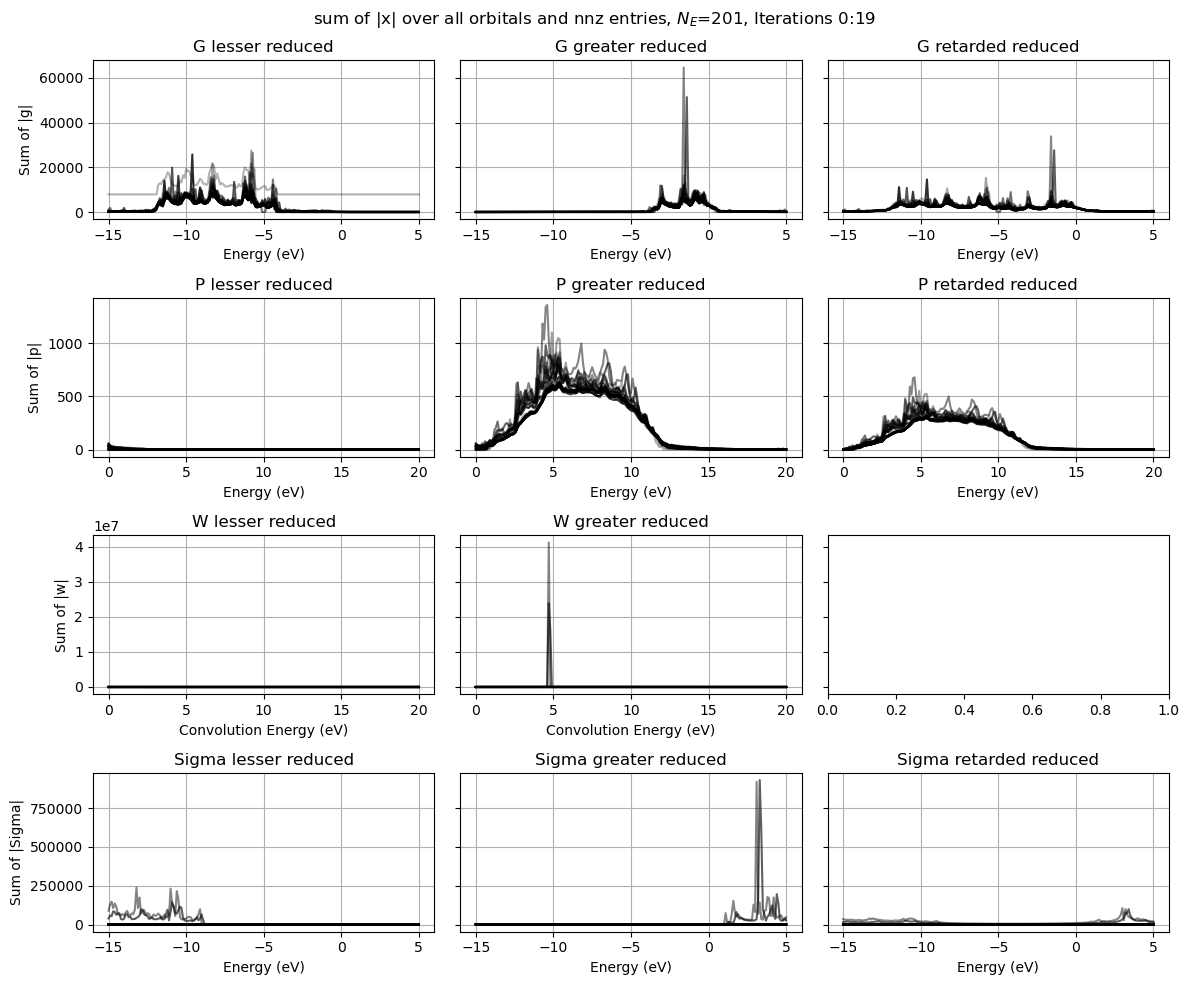

In [4]:
import numpy as np
from matplotlib import pyplot as plt

from quatrex.core.config import parse_config
from pathlib import Path
import os.path

# band-limited study
# 20260319_160518_energy201_iter20_reduced
# 20260319_154430_energy2001_iter20_reduced                     # reference, 20 iterations
# 20260319_161440_energy20001_iter5_reduced

# re-run reference
# 20260402_115320_energy201_iter20_reduced                      # re-run symmetrization off (matched peak filtering setting as band-limited 201 energies), 100 ranks
# 20260402_115829_energy201_iter20_reduced                      # ^same, but 50 ranks

# symmetrization on
# 20260402_120846_energy201_iter20_reduced         # 50 ranks
# 20260402_122703_energy201_iter20_reduced         # 50 ranks, re-run
# 20260402_121123_energy201_iter20_reduced         # 100 ranks
# 20260402_121428_energy201_iter20_reduced         # 201 ranks

# sanity check
# 20260326_153844_energy2001_iter20_adaptive_iter1_r1_reduced_sanity_check         # interpolation workflow, but _compute_adaptive_grid returns uniform grid

# adaptive comparison
# 20260326_144050_energy2001_iter100_adaptive_iter1_r1_reduced                      # 100 iterations
# 20260326_160928_energy2001_iter20_adaptive_iter1_r0p5_reduced                     # r=0.5
# 20260326_164806_energy201_iter20_adaptive_iter5_r1_reduced                        # adaptive start iteration 5, but 201 points (MPI stall for more 2001 energies)
# 20260331_134632_energy2001_iter20_adaptive_iter3_r1_reduced                       # adaptive start iteration 3, with 2001 energy points (adaptive start iteration 4 and 5 had MPI stall)
# 20260330_165159_energy2001_iter20_adaptive_iter2_r1_reduced                       # adaptive start itertion 2
# 20260330_171533_energy2001_iter20_adaptive_iter2_r1_reduced_g_sigma_source_points                # ^same, but use g+sigma as the source for computing the adaptive grid, instead of just g, iteration 2 because iteration 1 -> grid computed in iteration 0, sigma is zero

# bug fix: sigma_retarded computed with blown up grid for Hilbert transform
# 20260401_143119_energy201_iter20_adaptive_iter1_r1_reduced       # using 201 energies (currents look much better), 2001 fails with high error for OBCSolver Spectral, values collapse to 1e-30
# 20260402_112837_energy201_iter20_adaptive_iter1_r1_reduced       # re-run with symmetrization turned off (for saving the correct corresponding g_retarded nnz indices)
# 20260401_161530_energy2001_iter5_adaptive_iter1_r1_reduced       # run 2001 energies with 5 iterations just to see the blow up, run with 250 ranks
# 20260401_162521_energy2001_iter5_adaptive_iter1_r1_reduced       # run 2001 energies with 5 iterations just to see the blow up, run with 100 ranks ^ **different results**
# 20260401_164253_energy201_iter20_adaptive_iter5_r1_reduced       # run with 50 ranks

simulation_dir = Path("./../../examples/w90/carbon-nanotube/gw")
output_dir = simulation_dir / "outputs"
archive_dir = simulation_dir / "archive" / "20260402_121123_energy201_iter20_reduced"

# change these to switch between 'output' and 'archive'
data_files = 'archive'

# region: === load data ===
if data_files == 'output':
    data_dir = output_dir
    config_dir = simulation_dir
elif data_files == 'archive':
    data_dir = archive_dir
    config_dir = archive_dir
else:    
    raise ValueError(f"Invalid data_files value: {data_files}. Must be 'output' or 'archive'.")

config = parse_config(config_dir / "quatrex_config.toml")
iterations = range(0, config.scba.max_iterations)
# iterations = [0,1]

if os.path.exists(config_dir / "electron_energies.npy"):
    electron_energies = np.load(config_dir / "electron_energies.npy")
else:
    electron_energies = np.linspace(
        config.electron.energy_window_min,
        config.electron.energy_window_max,
        config.electron.energy_window_num,
    )
conv_energies = np.linspace(0, max(electron_energies) - min(electron_energies), len(electron_energies))

# preallocate arrays
g_lesser_reduced = np.empty((config.scba.max_iterations, len(electron_energies)))
g_greater_reduced = np.empty((config.scba.max_iterations, len(electron_energies)))
g_retarded_reduced = np.empty((config.scba.max_iterations, len(electron_energies)))

p_lesser_reduced = np.empty((config.scba.max_iterations, len(conv_energies)))
p_greater_reduced = np.empty((config.scba.max_iterations, len(conv_energies)))
p_retarded_reduced = np.empty((config.scba.max_iterations, len(conv_energies)))

w_lesser_reduced = np.empty((config.scba.max_iterations, len(conv_energies)))
w_greater_reduced = np.empty((config.scba.max_iterations, len(conv_energies)))

sigma_lesser_reduced = np.empty((config.scba.max_iterations, len(electron_energies)))
sigma_greater_reduced = np.empty((config.scba.max_iterations, len(electron_energies)))
sigma_retarded_reduced = np.empty((config.scba.max_iterations, len(electron_energies)))

adaptive_electron_energies_for_g_sigma = None
adaptive_electron_energies_for_p_w = None

# load data

for iteration in iterations:
    g_lesser_reduced[iteration] = np.load(data_dir / f"g_lesser_reduced_step_{iteration}.npy")
    g_greater_reduced[iteration] = np.load(data_dir / f"g_greater_reduced_step_{iteration}.npy")
    g_retarded_reduced[iteration] = np.load(data_dir / f"g_retarded_reduced_step_{iteration}.npy")

    p_lesser_reduced[iteration] = np.load(data_dir / f"p_lesser_reduced_step_{iteration}.npy")
    p_greater_reduced[iteration] = np.load(data_dir / f"p_greater_reduced_step_{iteration}.npy")
    p_retarded_reduced[iteration] = np.load(data_dir / f"p_retarded_reduced_step_{iteration}.npy")

    w_lesser_reduced[iteration] = np.load(data_dir / f"w_lesser_reduced_step_{iteration}.npy")
    w_greater_reduced[iteration] = np.load(data_dir / f"w_greater_reduced_step_{iteration}.npy")

    sigma_lesser_reduced[iteration] = np.load(data_dir / f"sigma_lesser_reduced_step_{iteration}.npy")
    sigma_greater_reduced[iteration] = np.load(data_dir / f"sigma_greater_reduced_step_{iteration}.npy")
    sigma_retarded_reduced[iteration] = np.load(data_dir / f"sigma_retarded_reduced_step_{iteration}.npy")

# load adaptive grids
if os.path.exists(f"{data_dir}/adaptive_electron_energies_for_g_sigma.npy"):
    adaptive_electron_energies_for_g_sigma = np.load(
        f"{data_dir}/adaptive_electron_energies_for_g_sigma.npy"
    )
else:
    print(
        f"Warning: adaptive electron energies for g and sigma file {data_dir}/adaptive_electron_energies_for_g_sigma.npy not found. This data will be None."
    )

if os.path.exists(f"{data_dir}/adaptive_electron_energies_for_p_w.npy"):
    adaptive_electron_energies_for_p_w = np.load(
        f"{data_dir}/adaptive_electron_energies_for_p_w.npy"
    )
else:
    print(
        f"Warning: adaptive electron energies for p and w file {data_dir}/adaptive_electron_energies_for_p_w.npy not found. This data will be None."
    )


# endregion

# region: === plotting ===
# plot all iterations on the same plot
fig, axs = plt.subplots(4,3, figsize=(12, 10), sharey='row')
for iteration in iterations:
    if iteration < config.scba.adaptive_start_iteration or adaptive_electron_energies_for_g_sigma is None:
        g_energies = electron_energies
        p_energies = conv_energies
        w_energies = conv_energies
        sigma_energies = electron_energies
        linestyle = "-"
        title_suffix = ""
    else:
        g_energies = adaptive_electron_energies_for_g_sigma
        p_energies = adaptive_electron_energies_for_p_w
        w_energies = adaptive_electron_energies_for_p_w
        sigma_energies = adaptive_electron_energies_for_g_sigma
        linestyle = "."
        title_suffix = " (adaptive grid)"

    markersize=2

    axs[0,0].plot(g_energies, g_lesser_reduced[iteration], linestyle, markersize=markersize, color='black', alpha=0.3 + 0.7 * (iteration / (config.scba.max_iterations - 1)), label=f"Iteration {iteration}")
    axs[0,1].plot(g_energies, g_greater_reduced[iteration], linestyle, markersize=markersize, color='black', alpha=0.3 + 0.7 * (iteration / (config.scba.max_iterations - 1)), label=f"Iteration {iteration}")
    axs[0,2].plot(g_energies, g_retarded_reduced[iteration], linestyle, markersize=markersize, color='black', alpha=0.3 + 0.7 * (iteration / (config.scba.max_iterations - 1)), label=f"Iteration {iteration}")

    axs[1,0].plot(p_energies, p_lesser_reduced[iteration], linestyle, markersize=markersize, color='black', alpha=0.3 + 0.7 * (iteration / (config.scba.max_iterations - 1)), label=f"Iteration {iteration}")
    axs[1,1].plot(p_energies, p_greater_reduced[iteration], linestyle, markersize=markersize, color='black', alpha=0.3 + 0.7 * (iteration / (config.scba.max_iterations - 1)), label=f"Iteration {iteration}")
    axs[1,2].plot(p_energies, p_retarded_reduced[iteration], linestyle, markersize=markersize, color='black', alpha=0.3 + 0.7 * (iteration / (config.scba.max_iterations - 1)), label=f"Iteration {iteration}")

    axs[2,0].plot(w_energies, w_lesser_reduced[iteration], linestyle, markersize=markersize, color='black', alpha=0.3 + 0.7 * (iteration / (config.scba.max_iterations - 1)), label=f"Iteration {iteration}")
    axs[2,1].plot(w_energies, w_greater_reduced[iteration], linestyle, markersize=markersize, color='black', alpha=0.3 + 0.7 * (iteration / (config.scba.max_iterations - 1)), label=f"Iteration {iteration}")
    
    axs[3,0].plot(sigma_energies, sigma_lesser_reduced[iteration], linestyle, markersize=markersize, color='black', alpha=0.3 + 0.7 * (iteration / (config.scba.max_iterations - 1)), label=f"Iteration {iteration}")
    axs[3,1].plot(sigma_energies, sigma_greater_reduced[iteration], linestyle, markersize=markersize, color='black', alpha=0.3 + 0.7 * (iteration / (config.scba.max_iterations - 1)), label=f"Iteration {iteration}")
    axs[3,2].plot(sigma_energies, sigma_retarded_reduced[iteration], linestyle, markersize=markersize, color='black', alpha=0.3 + 0.7 * (iteration / (config.scba.max_iterations - 1)), label=f"Iteration {iteration}")
# endregion

# region: === plotting labels ===
axs[0,0].set_title(f"G lesser reduced")
axs[0,0].set_xlabel("Energy (eV)")
axs[0,0].set_ylabel("Sum of |g|")
# axs[0,0].legend()
axs[0,0].grid()

axs[0,1].set_title(f"G greater reduced")
axs[0,1].set_xlabel("Energy (eV)")
# axs[0,1].legend()
axs[0,1].grid()

axs[0,2].set_title(f"G retarded reduced")
axs[0,2].set_xlabel("Energy (eV)")
# axs[0,2].legend()
axs[0,2].grid()

axs[1,0].set_title(f"P lesser reduced")
axs[1,0].set_xlabel("Energy (eV)")
axs[1,0].set_ylabel("Sum of |p|")
# axs[1,0].legend()
axs[1,0].grid()

axs[1,1].set_title(f"P greater reduced")
axs[1,1].set_xlabel("Energy (eV)")
# axs[1,1].legend()
axs[1,1].grid()

axs[1,2].set_title(f"P retarded reduced")
axs[1,2].set_xlabel("Energy (eV)")
# axs[1,2].legend()
axs[1,2].grid()

axs[2,0].set_title(f"W lesser reduced")
axs[2,0].set_xlabel("Convolution Energy (eV)")
axs[2,0].set_ylabel("Sum of |w|")
# axs[2,0].legend()
axs[2,0].grid()

axs[2,1].set_title(f"W greater reduced")
axs[2,1].set_xlabel("Convolution Energy (eV)")
# axs[2,1].legend()
axs[2,1].grid()

axs[3,0].set_title(f"Sigma lesser reduced")
axs[3,0].set_xlabel("Energy (eV)")
axs[3,0].set_ylabel("Sum of |Sigma|")
# axs[3,0].legend()
axs[3,0].grid()

axs[3,1].set_title(f"Sigma greater reduced")
axs[3,1].set_xlabel("Energy (eV)")
# axs[3,1].legend()
axs[3,1].grid()

axs[3,2].set_title(f"Sigma retarded reduced")
axs[3,2].set_xlabel("Energy (eV)")
# axs[3,2].legend()
axs[3,2].grid()

plt.suptitle(f"sum of |x| over all orbitals and nnz entries, $N_E$={len(electron_energies)}, Iterations {iterations[0]}:{iterations[-1]} {title_suffix}")
plt.tight_layout()
plt.show()
# endregion


## adaptive grid on first adaptive iteration
04 Feb 2026

When the adaptive grid is computed when iteration num == adaptive_start_iteration, we save it to disk. Just plot this.

In [5]:
adaptive_energies_g_sigma = np.load(data_dir / "adaptive_electron_energies_for_g_sigma.npy")

plt.plot(adaptive_energies_g_sigma, np.zeros_like(adaptive_energies_g_sigma), 'o')
plt.title("Adaptive Electron Energy Grid Points")
plt.xlabel("Energy (eV)")
plt.grid()
plt.xlim(config.electron.energy_window_min, config.electron.energy_window_max)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../../examples/w90/carbon-nanotube/gw/archive/20260402_121123_energy201_iter20_reduced/adaptive_electron_energies_for_g_sigma.npy'

## debugging adaptive interpolation workflow

Thurs, Mar 19, 2026

The adaptive interpolation fft workflow switches from uniform to adaptive grid after iteration 1. In iteration 2, the polarization is calculated using the source adaptive grid (g retarded) > interpolate to fine grid > ifft(fft * fft) > interpolate to target adaptive grid (p retarded). But the the polarization is always a straight line. Not sure why. I've dumped out the full convolution `p_g_full` variable. Let's compare between the uniform iteration 0/1 and adaptive iteration 2/3.

Only run this with the 2x sections of `(liyongda 19 Mar 2026): debugging saves` uncommented. Run quatrex with 1 rank.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

# uniform iteration 0,1
g_greater0 = np.load(data_dir / f"g_greater_0.npy")
g_lesser0 = np.load(data_dir / f"g_lesser_0.npy")
g_greater1 = np.load(data_dir / f"g_greater_1.npy")
g_lesser1 = np.load(data_dir / f"g_lesser_1.npy")

p_g_full0 = np.load(data_dir / f"p_g_full_iter0.npy")
p_g_full1 = np.load(data_dir / f"p_g_full_iter1.npy")
energies_conv0 = np.load(data_dir / f"energies_conv_iter0.npy")
energies_conv1 = np.load(data_dir / f"energies_conv_iter1.npy")

# adaptive iteration 2,3

## before interpolation
source_adaptive_points2 = np.load(data_dir / f"source_adaptive_points_iter2.npy")
g_greater2 = np.load(data_dir / f"g_greater_2.npy")
g_lesser2 = np.load(data_dir / f"g_lesser_2.npy")

source_adaptive_points3 = np.load(data_dir / f"source_adaptive_points_iter3.npy")
g_greater3 = np.load(data_dir / f"g_greater_3.npy")
g_lesser3 = np.load(data_dir / f"g_lesser_3.npy")

## after interpolation
fine_energies_adaptive = np.load(data_dir / f"fine_energies_adaptive_iter2.npy")
g_greater_fine2 = np.load(data_dir / f"g_greater_fine_adaptive_iter2.npy")
g_lesser_fine2 = np.load(data_dir / f"g_lesser_fine_adaptive_iter2.npy")
g_greater_fine3 = np.load(data_dir / f"g_greater_fine_adaptive_iter3.npy")
g_lesser_fine3 = np.load(data_dir / f"g_lesser_fine_adaptive_iter3.npy")

p_g_full_adaptive2 = np.load(data_dir / f"p_g_full_adaptive_iter2.npy")
p_g_full_adaptive3 = np.load(data_dir / f"p_g_full_adaptive_iter3.npy")
fine_energies_conv2 = np.load(data_dir / f"energies_conv_adaptive_iter2.npy")
fine_energies_conv3 = np.load(data_dir / f"energies_conv_adaptive_iter3.npy")

nnz_idx = 34

plot_full = True
if plot_full:
    fig, axs = plt.subplots(2,2, figsize=(12,6), sharey='row')
    axs[0,0].set_title("real (g_greater)")
    axs[0,0].plot(SCBADataObj.energies, g_greater0[:,nnz_idx].real, label=f'uniform 0, N={len(SCBADataObj.energies)}')
    axs[0,0].plot(SCBADataObj.energies, g_greater1[:,nnz_idx].real, label=f'uniform 1, N={len(SCBADataObj.energies)}')
    axs[0,0].plot(fine_energies_adaptive, g_greater_fine2[:,nnz_idx].real, label=f'adaptive 2, N={len(fine_energies_adaptive)}')
    axs[0,0].plot(fine_energies_adaptive, g_greater_fine3[:,nnz_idx].real, label=f'adaptive 3, N={len(fine_energies_adaptive)}')
    axs[0,0].set_xlabel("Electron Energies [eV]")
    axs[0,0].legend()
    axs[0,0].grid()

    axs[0,1].set_title("imag (g_greater)")
    axs[0,1].plot(SCBADataObj.energies, g_greater0[:,nnz_idx].imag, label=f'uniform 0, N={len(SCBADataObj.energies)}')
    axs[0,1].plot(SCBADataObj.energies, g_greater1[:,nnz_idx].imag, label=f'uniform 1, N={len(SCBADataObj.energies)}')
    axs[0,1].plot(fine_energies_adaptive, g_greater_fine2[:,nnz_idx].imag, label=f'adaptive 2, N={len(fine_energies_adaptive)}')
    axs[0,1].plot(fine_energies_adaptive, g_greater_fine3[:,nnz_idx].imag, label=f'adaptive 3, N={len(fine_energies_adaptive)}')
    axs[0,1].set_xlabel("Electron Energies [eV]")
    axs[0,1].legend()
    axs[0,1].grid()

    axs[1,0].set_title("real (p_g_full)")
    axs[1,0].plot(energies_conv0, p_g_full0[:,nnz_idx].real, label=f'uniform 0, N={len(energies_conv0)}')
    axs[1,0].plot(energies_conv1, p_g_full1[:,nnz_idx].real, label=f'uniform 1, N={len(energies_conv1)}')
    axs[1,0].plot(fine_energies_conv2, p_g_full_adaptive2[:,nnz_idx].real, label=f'adaptive 2, N={len(fine_energies_conv2)}')
    axs[1,0].plot(fine_energies_conv3, p_g_full_adaptive3[:,nnz_idx].real, label=f'adaptive 3, N={len(fine_energies_conv3)}')
    axs[1,0].set_xlabel("Electron Energies [eV]")
    axs[1,0].legend()
    axs[1,0].grid()

    axs[1,1].set_title("imag (p_g_full)")
    axs[1,1].plot(energies_conv0, p_g_full0[:,nnz_idx].imag, label=f'uniform 0, N={len(energies_conv0)}')
    axs[1,1].plot(energies_conv1, p_g_full1[:,nnz_idx].imag, label=f'uniform 1, N={len(energies_conv1)}')
    axs[1,1].plot(fine_energies_conv2, p_g_full_adaptive2[:,nnz_idx].imag, label=f'adaptive 2, N={len(fine_energies_conv2)}')
    axs[1,1].plot(fine_energies_conv3, p_g_full_adaptive3[:,nnz_idx].imag, label=f'adaptive 3, N={len(fine_energies_conv3)}')
    axs[1,1].set_xlabel("Electron Energies [eV]")
    axs[1,1].legend()
    axs[1,1].grid()

    plt.tight_layout()
    plt.show()

plot_interp2 = True
if plot_interp2:
    fig, axs = plt.subplots(2,2, figsize=(12,6), sharex='col', sharey='row')
    axs[0,0].set_title("real (g_greater)")
    axs[0,0].plot(source_adaptive_points2, g_greater2[:,nnz_idx].real, ".", label=f'before interp 2, N={len(source_adaptive_points2)}')
    axs[0,0].plot(fine_energies_adaptive, g_greater_fine2[:,nnz_idx].real, label=f'after interp 2, N={len(fine_energies_adaptive)}')
    axs[0,0].set_xlabel("Electron Energies [eV]")
    axs[0,0].legend()
    axs[0,0].grid()

    axs[0,1].set_title("imag (g_greater)")
    axs[0,1].plot(source_adaptive_points2, g_greater2[:,nnz_idx].imag, ".", label=f'before interp 2, N={len(source_adaptive_points2)}')
    axs[0,1].plot(fine_energies_adaptive, g_greater_fine2[:,nnz_idx].imag, label=f'after interp 2, N={len(fine_energies_adaptive)}')
    axs[0,1].set_xlabel("Electron Energies [eV]")
    axs[0,1].legend()
    axs[0,1].grid()

    axs[1,0].set_title("real (g_lesser)")
    axs[1,0].plot(source_adaptive_points2, g_lesser2[:,nnz_idx].real, ".", label=f'before interp 2, N={len(source_adaptive_points2)}')
    axs[1,0].plot(fine_energies_adaptive, g_lesser_fine2[:,nnz_idx].real, label=f'after interp 2, N={len(fine_energies_adaptive)}')
    axs[1,0].set_xlabel("Electron Energies [eV]")
    axs[1,0].legend()
    axs[1,0].grid()

    axs[1,1].set_title("imag (g_lesser)")
    axs[1,1].plot(source_adaptive_points2, g_lesser2[:,nnz_idx].imag, ".", label=f'before interp 2, N={len(source_adaptive_points2)}')
    axs[1,1].plot(fine_energies_adaptive, g_lesser_fine2[:,nnz_idx].imag, label=f'after interp 2, N={len(fine_energies_adaptive)}')
    axs[1,1].set_xlabel("Electron Energies [eV]")
    axs[1,1].legend()
    axs[1,1].grid()

    plt.suptitle("Iteration 2: g greater and lesser before and after interpolation")
    plt.tight_layout()
    plt.show()

plot_interp3 = False
if plot_interp3:
    fig, axs = plt.subplots(2,2, figsize=(12,6), sharex='col', sharey='row')
    axs[0,0].set_title("real (g_greater)")
    axs[0,0].plot(source_adaptive_points3, g_greater3[:,nnz_idx].real, ".", label=f'before interp 3, N={len(source_adaptive_points3)}')
    axs[0,0].plot(fine_energies_adaptive, g_greater_fine3[:,nnz_idx].real, label=f'after interp 3, N={len(fine_energies_adaptive)}')
    axs[0,0].set_xlabel("Electron Energies [eV]")
    axs[0,0].legend()
    axs[0,0].grid()

    axs[0,1].set_title("imag (g_greater)")
    axs[0,1].plot(source_adaptive_points3, g_greater3[:,nnz_idx].imag, ".", label=f'before interp 3, N={len(source_adaptive_points3)}')
    axs[0,1].plot(fine_energies_adaptive, g_greater_fine3[:,nnz_idx].imag, label=f'after interp 3, N={len(fine_energies_adaptive)}')
    axs[0,1].set_xlabel("Electron Energies [eV]")
    axs[0,1].legend()
    axs[0,1].grid()

    axs[1,0].set_title("real (g_lesser)")
    axs[1,0].plot(source_adaptive_points3, g_lesser3[:,nnz_idx].real, ".", label=f'before interp 3, N={len(source_adaptive_points3)}')
    axs[1,0].plot(fine_energies_adaptive, g_lesser_fine3[:,nnz_idx].real, label=f'after interp 3, N={len(fine_energies_adaptive)}')
    axs[1,0].set_xlabel("Electron Energies [eV]")
    axs[1,0].legend()
    axs[1,0].grid()

    axs[1,1].set_title("imag (g_lesser)")
    axs[1,1].plot(source_adaptive_points3, g_lesser3[:,nnz_idx].imag, ".", label=f'before interp 3, N={len(source_adaptive_points3)}')
    axs[1,1].plot(fine_energies_adaptive, g_lesser_fine3[:,nnz_idx].imag, label=f'after interp 3, N={len(fine_energies_adaptive)}')
    axs[1,1].set_xlabel("Electron Energies [eV]")
    axs[1,1].legend()
    axs[1,1].grid()


    plt.suptitle("Iteration 3: g greater and lesser before and after interpolation")
    plt.tight_layout()
    plt.show()



# Spectrogram
Thurs, Dec 18, 2025

After doing some literature review on "multi-resolution analysis", I think it would be interesting to view the spectrogram of the Green's function. Maybe there's some hidden pattern in the density of states. I think it might give some more info into what frequency and time data is most important to capture.

## Gabor Transform
https://www.youtube.com/watch?v=EfWnEldTyPA

The idea is to do a Fourier transform, but convolve the function with a Gaussian first ($x(t) e^{- \pi (t-\tau)^2}$). The result is a function (aka Gabor transform) that is both a function of time and frequency. You don't have the same time resolution of time-series data, and you also don't have the frequency resolution of a Fourier transform, but you have some resolution in both dimensions.

$$
G_x(\tau, \omega) = \int^{\infty}_{-\infty}x(t) e^{- \pi (t-\tau)^2} e^{-j\omega t}dt
$$

You can change the width of the Gaussian to change the windowing length.

## SciPy Spectrogram
Unfortunately, the `scipy.signal.spectrogram` [function is considered legacy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.spectrogram.html). We'll use ths [short-time FFT to produce the spectrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.ShortTimeFFT.spectrogram.html#scipy.signal.ShortTimeFFT.spectrogram), which is the new recommended way. It's just the square of the short-time FFT, to ensure that the output is always positive. We choose the window function to be a Gaussian.

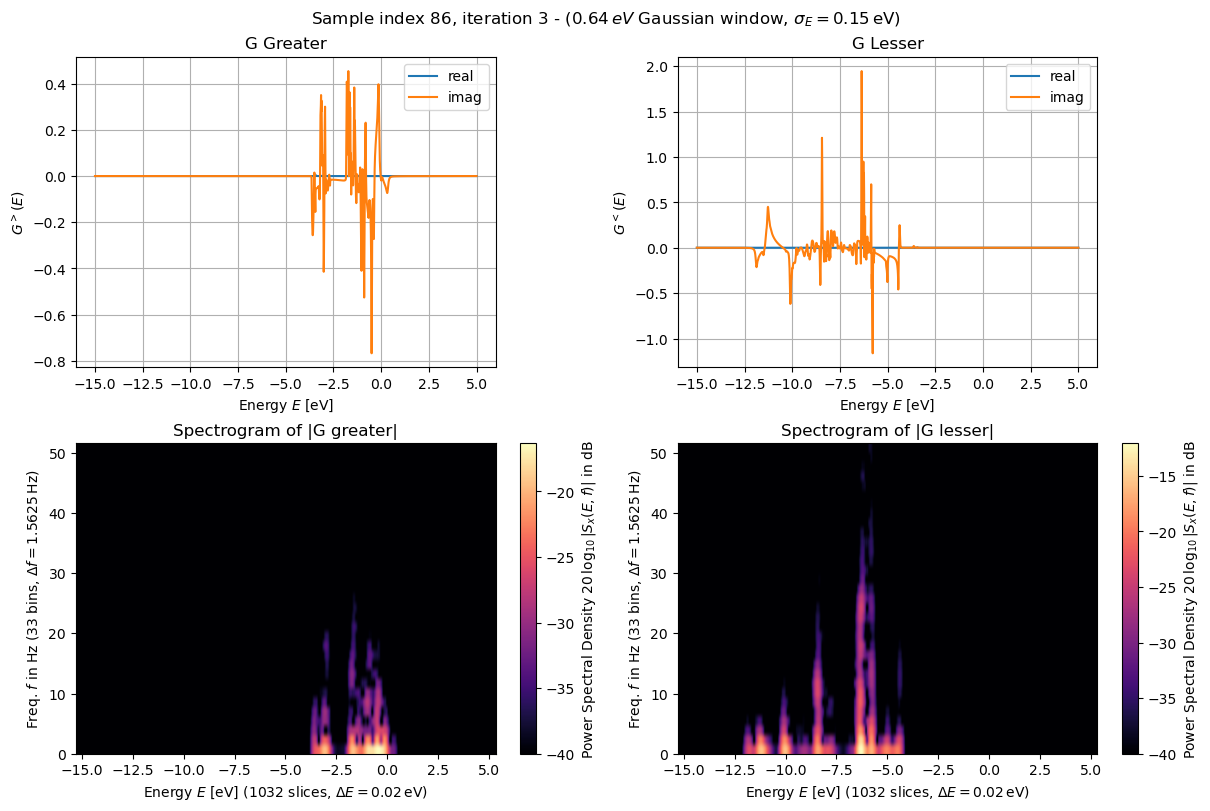

In [4]:
import numpy as np
from quatrex.core.config import parse_config
from pathlib import Path
from matplotlib import pyplot as plt

from scba_container.scba_container import SCBAContainer
from scipy.signal import square, ShortTimeFFT
from scipy.signal.windows import gaussian

# 20260226_152224_energy201_iter20_reduced
# 20260226_155038_energy2001_iter5_reduced
# 20260227_113823_energy20001_iter5_reduced

simulation_dir = Path("./../../examples/w90/carbon-nanotube/gw")
output_dir = simulation_dir / "outputs"
output_file_prefix = output_dir / "visualize_scba"
archive_dir = simulation_dir / "archive" / "20260416_145226_energy2001_iter100_rank250"
archive_file_prefix = archive_dir / "visualize_scba"

# change these to switch between output and archive
data_files = 'archive'

# === user parameters ===
iteration = 3
sample_idx = 86

# region: === load data ===
if data_files == 'output':
    data_file_prefix = output_file_prefix
    config_dir = simulation_dir
elif data_files == 'archive':
    data_file_prefix = archive_file_prefix
    config_dir = archive_dir
else:
    raise ValueError(f"Invalid data_files value: {data_files}. Must be 'output' or 'archive'.")

config = parse_config(config_dir / "quatrex_config.toml")

max_idx = 43823  # total nnz entries - 1
sample_indices = np.load(f"{data_file_prefix}_sample_indices.npy")
num_samples = len(sample_indices)

SCBADataObj = SCBAContainer(
    max_iterations=config.scba.max_iterations,
    energy_window_min=config.electron.energy_window_min,
    energy_window_max=config.electron.energy_window_max,
    energy_window_num=config.electron.energy_window_num,
    num_samples=num_samples,
)

SCBADataObj.load_sample_indices(data_file_prefix)

for i in range(config.scba.max_iterations):
    SCBADataObj.load_g_data(data_file_prefix, iteration=i)
    SCBADataObj.load_p_data(data_file_prefix, iteration=i)
    SCBADataObj.load_w_data(data_file_prefix, iteration=i)
    SCBADataObj.load_sigma_data(data_file_prefix, iteration=i)

assert (
    sample_idx <= num_samples
), f"sample_idx={sample_idx} exceeds num_samples={num_samples}"
nnz_index = SCBADataObj.sample_indices[sample_idx]

g_lesser = SCBADataObj.g_lesser[iteration, :, sample_idx]
g_greater = SCBADataObj.g_greater[iteration, :, sample_idx]
p_lesser = SCBADataObj.p_lesser[iteration, :, sample_idx]
p_greater = SCBADataObj.p_greater[iteration, :, sample_idx]
# endregion

# prepare spectrogram parameters
dE = np.abs(
    SCBADataObj.energies[1] - SCBADataObj.energies[0]
)  # sampling interval in time domain corresponding to energy grid spacing
N = len(SCBADataObj.energies)

# user parameters for spectrogram
g_std = 15  # standard deviation for Gaussian window in samples
g_M = 64  # window length in samples

win = gaussian(g_M, std=g_std, sym=True)  # symmetric Gaussian window
SFT = ShortTimeFFT(win, hop=2, fs=1 / dE, scale_to="psd")

# compute spectrograms
Sx_greater = SFT.spectrogram(np.abs(g_greater))  # calculate absolute square of STFT
Sx_lesser = SFT.spectrogram(np.abs(g_lesser))  # calculate absolute square of STFT

# region: === plotting ===
fig, axs = plt.subplots(
    2, 2, figsize=(12, 8), layout="constrained"
)  # constrained layout to lineup the x-axis

axs[0, 0].set_title(f"G Greater")
axs[0, 0].plot(SCBADataObj.energies, np.real(g_greater), label="real")
axs[0, 0].plot(SCBADataObj.energies, np.imag(g_greater), label="imag")
axs[0, 0].set(xlabel="Energy $E$ [eV]", ylabel=r"$G^{>}(E)$")
axs[0, 0].legend()
axs[0, 0].grid()

axs[0, 1].set_title(f"G Lesser")
axs[0, 1].plot(SCBADataObj.energies, np.real(g_lesser), label="real")
axs[0, 1].plot(SCBADataObj.energies, np.imag(g_lesser), label="imag")
axs[0, 1].set(xlabel="Energy $E$ [eV]", ylabel=r"$G^{<}(E)$")
axs[0, 1].legend()
axs[0, 1].grid()


t_lo, t_hi, f_lo, f_hi = SFT.extent(N)
t_lo += SCBADataObj.energies[0]
t_hi += SCBADataObj.energies[0]

axs[1, 0].set_title(f"Spectrogram of |G greater|")
axs[1, 0].set(
    xlabel=f"Energy $E$ [eV] ({SFT.p_num(N)} slices, "
    + rf"$\Delta E = {SFT.delta_t:g}\,$eV)",
    ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, "
    + rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
    xlim=(t_lo, t_hi),
)
Sx_dB = 10 * np.log10(np.fmax(Sx_greater, 1e-4))  # limit range to -40 dB
im1 = axs[1, 0].imshow(
    Sx_dB, origin="lower", aspect="auto", extent=(t_lo, t_hi, f_lo, f_hi), cmap="magma"
)
fig.colorbar(im1, label="Power Spectral Density " + r"$20\,\log_{10}|S_x(E, f)|$ in dB")

axs[1, 1].set_title(f"Spectrogram of |G lesser|")
axs[1, 1].set(
    xlabel=f"Energy $E$ [eV] ({SFT.p_num(N)} slices, "
    + rf"$\Delta E = {SFT.delta_t:g}\,$eV)",
    ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, "
    + rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
    xlim=(t_lo, t_hi),
)
Sx_dB = 10 * np.log10(np.fmax(Sx_lesser, 1e-4))  # limit range to -40 dB
im2 = axs[1, 1].imshow(
    Sx_dB, origin="lower", aspect="auto", extent=(t_lo, t_hi, f_lo, f_hi), cmap="magma"
)
fig.colorbar(im2, label="Power Spectral Density " + r"$20\,\log_{10}|S_x(E, f)|$ in dB")

plt.suptitle(
    rf"Sample index {sample_idx}, iteration {iteration} - ({SFT.m_num*SFT.T:g}$\,eV$ Gaussian "
    + rf"window, $\sigma_E={g_std*SFT.T:g}\,$eV)"
)
plt.show()
# endregion

# Appendix

## reference code from scipy
https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.ShortTimeFFT.spectrogram.html#scipy.signal.ShortTimeFFT.spectrogram

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import square, ShortTimeFFT
from scipy.signal.windows import gaussian

T_x, N = 1 / 20, 1000  # 20 Hz sampling rate for 50 s signal
t_x = np.arange(N) * T_x  # time indexes for signal
f_i = 5e-3 * (t_x - t_x[N // 3]) ** 2 + 1  # varying frequency
x = square(2 * np.pi * np.cumsum(f_i) * T_x)  # the signal
g_std = 12  # standard deviation for Gaussian window in samples
win = gaussian(50, std=g_std, sym=True)  # symmetric Gaussian wind.
SFT = ShortTimeFFT(win, hop=2, fs=1 / T_x, mfft=800, scale_to="psd")
Sx2 = SFT.spectrogram(x)  # calculate absolute square of STFT
fig1, ax1 = plt.subplots(figsize=(6.0, 4.0))  # enlarge plot a bit
t_lo, t_hi = SFT.extent(N)[:2]  # time range of plot
ax1.set_title(
    rf"Spectrogram ({SFT.m_num*SFT.T:g}$\,s$ Gaussian "
    + rf"window, $\sigma_t={g_std*SFT.T:g}\,$s)"
)
ax1.set(
    xlabel=f"Time $t$ in seconds ({SFT.p_num(N)} slices, "
    + rf"$\Delta t = {SFT.delta_t:g}\,$s)",
    ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, "
    + rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
    xlim=(t_lo, t_hi),
)
Sx_dB = 10 * np.log10(np.fmax(Sx2, 1e-4))  # limit range to -40 dB
im1 = ax1.imshow(
    Sx_dB, origin="lower", aspect="auto", extent=SFT.extent(N), cmap="magma"
)
# ax1.plot(t_x, f_i, 'g--', alpha=.5, label='$f_i(t)$')
fig1.colorbar(
    im1, label="Power Spectral Density " + r"$20\,\log_{10}|S_x(t, f)|$ in dB"
)
# Shade areas where window slices stick out to the side:
# for t0_, t1_ in [(t_lo, SFT.lower_border_end[0] * SFT.T),
#                  (SFT.upper_border_begin(N)[0] * SFT.T, t_hi)]:
#     ax1.axvspan(t0_, t1_, color='w', linewidth=0, alpha=.3)
# for t_ in [0, N * SFT.T]:  # mark signal borders with vertical line
#     ax1.axvline(t_, color='c', linestyle='--', alpha=0.5)
# ax1.legend()
fig1.tight_layout()
plt.show()